# 2.1 Hybrid FDFK vs Fortran FDFK2D — test1 P-incident Benchmark

End-to-end comparison of the **Python hybrid FDFK** implementation against the
**Fortran FDFK2D** reference output for the `test1` P-incident benchmark case.

## Key points

- **Primary metric: `uz` (vertical displacement)**. For `ux`, the engine applies
  Fortran-compatible `cos(phi)` post-rotation by default (`fortran_seisx_convention=True`),
  so `result.ux` directly matches Fortran `seisx.su`. Set `fortran_seisx_convention=False`
  to get the single-cos profile-projected ux instead.
- **Source type: P-wave** (`Source.dat`: `.true.`).
- Case parameters: `nx=1001`, `nz≈31`, `nt=4001`, `nrcv=1001`.
- This notebook is **manual** (not run under pytest) due to the computational cost
  (~minutes on a laptop).

## Workflow

1. Load the test1 P-incident input deck from `benchmark/test1_P_out/input/`
2. Run `compute_hybrid_seismograms` (Python)
3. Load Fortran reference from `benchmark/test1_P_out/output/fortran/`
4. Compute waveform metrics (RMSE, NRMSE, CC)
5. Visual comparison (trace overlays)
6. Wavefield snapshot comparison (`ux`, `uz`)

## Pass criteria (starter thresholds — tune after first run)

| Metric | Threshold |
|--------|-----------|
| `uz` CC | > 0.95 |
| `uz` NRMSE | < 0.05 |

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Add project root to path
PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from fk.io_fortran import load_example, read_su, write_su, read_fk_model
from fk.geometry import rayp_deg_to_si
from hybrid.config import HybridConfig
from hybrid.engine import compute_hybrid_seismograms

BENCH_DIR = PROJECT_ROOT / "benchmark" / "test1_P_out"
BWF_PAD_FACTOR = 2.0  # anti-wraparound: match test1_P_out benchmark
print(f"Benchmark directory: {BENCH_DIR}")
print(f"Fortran output exists: {(BENCH_DIR / 'output' / 'fortran' / 'seisz.su').exists()}")

Benchmark directory: /Users/jygong/Stanford/Courses/GP245 Computational Earthsystem Analysis/Final Project/FDFK_Python/benchmark/test1_P_out
Fortran output exists: True


In [2]:
# --- Load test1 case (reuses run_python_benchmark.py logic) ---

def fortran_half_order(raw_order: int, npml: int) -> int:
    """Match Input.f90 norder conversion."""
    n = raw_order // 2
    if 2 * n > npml + 1:
        n = (npml + 1) // 2
    return n


def _model_stems(inpar_path: Path) -> tuple:
    lines = [ln.strip() for ln in inpar_path.read_text().splitlines() if ln.strip()]
    return lines[5], lines[6]


input_dir = BENCH_DIR / "input"
ex = load_example(input_dir, side="left")
fd = ex.fd

nx = int(round((fd.xn - fd.x0) / fd.dx)) + 1
nz = int(round((fd.zn - fd.z0) / fd.dz)) + 1

config = HybridConfig(
    nx=nx, nz=nz,
    dx=fd.dx, dz=fd.dz,
    x0=fd.x0, z0=fd.z0,
    dt=fd.dt, nt=fd.nt,
    norder=fd.norder,
    npml=fd.npml,
)

# Velocity model
vp_stem, vs_stem = _model_stems(input_dir / "inpar.dat")
vp_path = input_dir / (vp_stem.replace('.su', '') + '_without_pml.su')
vs_path = input_dir / (vs_stem.replace('.su', '') + '_without_pml.su')
vp_tr, _ = read_su(vp_path)
vs_tr, _ = read_su(vs_path)
vp_2d = vp_tr.T.astype(np.float64)
vs_2d = vs_tr.T.astype(np.float64)
rho_2d = (vp_2d + 980.0) / 2.760

# FK models
model_left = read_fk_model(input_dir / "FK_model_left.dat")
model_right = read_fk_model(input_dir / "FK_model_right.dat")
p_si = rayp_deg_to_si(ex.src.rayp_deg)

# z_init (matching Fortran convention)
vp_half = model_left.vp[model_left.halfspace_index]
sin_arg = min(1.0, max(-1.0, p_si * vp_half))
z_init = fd.zn + 0.5 * (nx - 1) * fd.dx * np.tan(np.arcsin(sin_arg))

print(f"Grid: nx={nx}, nz={nz}, nt={fd.nt}, norder={config.norder}, npml={config.npml}")
print(f"dt={config.dt:.5f}s, dx={config.dx:.1f}m, dz={config.dz:.1f}m")
print(f"Receivers: {ex.rx.size}")

Grid: nx=1001, nz=251, nt=4001, norder=8, npml=20
dt=0.01000s, dx=200.0m, dz=200.0m
Receivers: 401


In [3]:
# --- Run Python hybrid ---

print("Running compute_hybrid_seismograms...")
t0 = time.perf_counter()

result = compute_hybrid_seismograms(
    config,
    model_left,
    model_right,
    ex.source,
    p_si,
    receivers_x=ex.rx,
    receivers_z=ex.rz,
    vp_2d=vp_2d,
    vs_2d=vs_2d,
    rho_2d=rho_2d,
    phi=ex.phi,
    z_init=z_init,
    bwf_pad_factor=BWF_PAD_FACTOR,  # anti-wraparound: synthesise on ~2x time axis
    verbose=True,
)

wall_sec = time.perf_counter() - t0
print(f"\nPython wall time: {wall_sec:.2f} s")

# Optionally cache to disk
out_dir = BENCH_DIR / "output" / "python"
out_dir.mkdir(parents=True, exist_ok=True)
write_su(out_dir / "seisx.su", result.ux, config.dt)
write_su(out_dir / "seisz.su", result.uz, config.dt)
print(f"Cached Python output to {out_dir}")

Running compute_hybrid_seismograms...
[Hybrid] Computing FK background wavefield (nz=251, nx=1001, nt=4001)...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


[Hybrid] Background wavefield memory: 1472.0 MB
[Hybrid] Initializing FD solver...
[Hybrid] Time-stepping: 4001 steps, dt=0.01000s...
[Hybrid] Simulation complete.

Python wall time: 42.72 s
Cached Python output to /Users/jygong/Stanford/Courses/GP245 Computational Earthsystem Analysis/Final Project/FDFK_Python/benchmark/test1_P_out/output/python


In [4]:
# --- Load Fortran reference ---

fortran_dir = BENCH_DIR / "output" / "fortran"

f_seisz, f_dt_z = read_su(fortran_dir / "seisz.su")
f_seisx, f_dt_x = read_su(fortran_dir / "seisx.su")

print(f"Fortran seisz shape: {f_seisz.shape}, dt={f_dt_z:.5f}s")
print(f"Fortran seisx shape: {f_seisx.shape}, dt={f_dt_x:.5f}s")
print(f"Python  uz    shape: {result.uz.shape}")
print(f"Python  ux    shape: {result.ux.shape}")

Fortran seisz shape: (401, 4001), dt=0.01000s
Fortran seisx shape: (401, 4001), dt=0.01000s
Python  uz    shape: (401, 4001)
Python  ux    shape: (401, 4001)


In [5]:
# --- Waveform metrics ---

def waveform_metrics(python_data, fortran_data, component: str) -> dict:
    """Compute RMSE, NRMSE, CC between Python and Fortran seismograms."""
    if python_data.shape != fortran_data.shape:
        print(f"  WARNING: shape mismatch for {component}: "
              f"Python {python_data.shape} vs Fortran {fortran_data.shape}")
        # Truncate to common size
        nrcv = min(python_data.shape[0], fortran_data.shape[0])
        nt = min(python_data.shape[1], fortran_data.shape[1])
        python_data = python_data[:nrcv, :nt]
        fortran_data = fortran_data[:nrcv, :nt]

    diff = python_data.astype(np.float64) - fortran_data.astype(np.float64)
    rmse = float(np.sqrt(np.mean(diff**2)))
    denom = float(np.max(np.abs(fortran_data))) + 1e-30
    nrmse = rmse / denom
    cc = float(np.corrcoef(python_data.ravel(), fortran_data.ravel())[0, 1])
    return {"rmse": rmse, "nrmse": nrmse, "cc": cc}


met_uz = waveform_metrics(result.uz, f_seisz, "uz")
# result.ux already includes the Fortran-compatible cos(phi) post-rotation
# (fortran_seisx_convention=True by default). No manual rotation needed.
met_ux = waveform_metrics(result.ux, f_seisx, "ux (Fortran conv.)")

print("=" * 50)
print("Waveform metrics: Python hybrid vs Fortran FDFK2D")
print("=" * 50)
print(f"\n  uz (vertical — primary):")
print(f"    RMSE  = {met_uz['rmse']:.4e}")
print(f"    NRMSE = {met_uz['nrmse']:.4e}")
print(f"    CC    = {met_uz['cc']:.6f}")
print(f"\n  ux (Fortran-aligned; engine applies cos(phi) post-rotation by default):")
print(f"    RMSE  = {met_ux['rmse']:.4e}")
print(f"    NRMSE = {met_ux['nrmse']:.4e}")
print(f"    CC    = {met_ux['cc']:.6f}")
print(f"    cos(phi) = {np.cos(ex.phi):+.4f}")

# Pass/fail assessment
UZ_CC_THRESH = 0.95
UZ_NRMSE_THRESH = 0.05

print("\n" + "-" * 50)
uz_pass = met_uz["cc"] > UZ_CC_THRESH and met_uz["nrmse"] < UZ_NRMSE_THRESH
status = "PASS" if uz_pass else "FAIL"
print(f"uz assessment: {status}")
print(f"  CC={met_uz['cc']:.4f} (threshold > {UZ_CC_THRESH})")
print(f"  NRMSE={met_uz['nrmse']:.4e} (threshold < {UZ_NRMSE_THRESH})")
if not uz_pass:
    print("  >> Investigate differences; tune thresholds if first run.")

Waveform metrics: Python hybrid vs Fortran FDFK2D

  uz (vertical — primary):
    RMSE  = 2.2354e-04
    NRMSE = 7.6532e-02
    CC    = 0.236029

  ux (Fortran-aligned; engine applies cos(phi) post-rotation by default):
    RMSE  = 1.5861e-04
    NRMSE = 9.0938e-02
    CC    = 0.306460
    cos(phi) = -0.9916

--------------------------------------------------
uz assessment: FAIL
  CC=0.2360 (threshold > 0.95)
  NRMSE=7.6532e-02 (threshold < 0.05)
  >> Investigate differences; tune thresholds if first run.


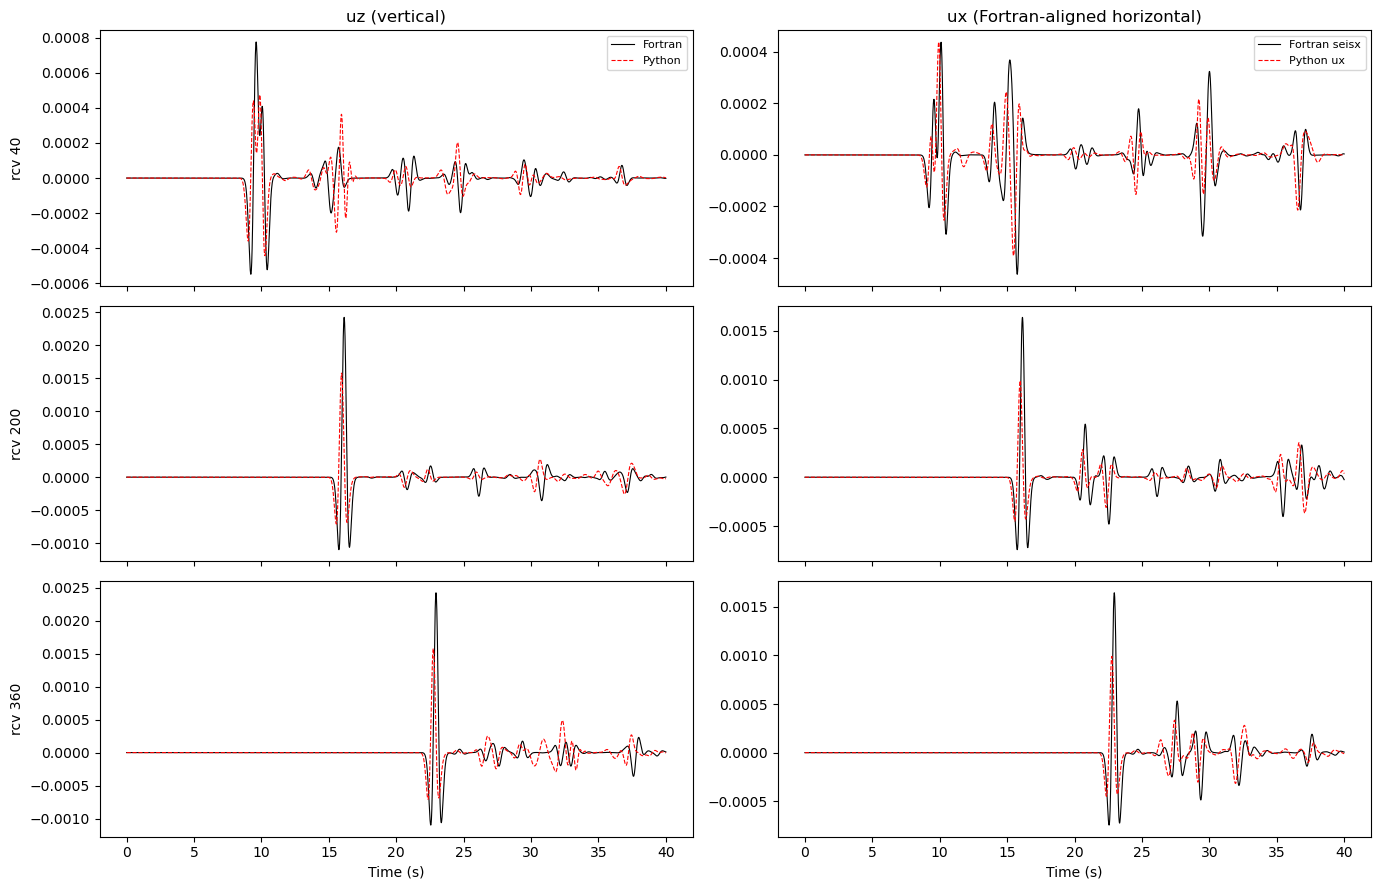

Saved trace_comparison.png


In [6]:
# --- Visual comparison: trace overlays ---

nrcv = result.uz.shape[0]
t = np.arange(result.uz.shape[1]) * config.dt

# Select receiver indices for comparison
rcv_indices = [nrcv // 10, nrcv // 2, 9 * nrcv // 10]

fig, axes = plt.subplots(len(rcv_indices), 2, figsize=(14, 3 * len(rcv_indices)),
                         sharex=True)

for row, ircv in enumerate(rcv_indices):
    # uz comparison
    ax = axes[row, 0]
    ax.plot(t, f_seisz[ircv], 'k-', lw=0.8, label='Fortran')
    ax.plot(t, result.uz[ircv], 'r--', lw=0.8, label='Python')
    ax.set_ylabel(f'rcv {ircv}')
    if row == 0:
        ax.set_title('uz (vertical)')
        ax.legend(loc='upper right', fontsize=8)

    # ux comparison (engine applies Fortran-compatible cos(phi) rotation by default)
    ax = axes[row, 1]
    ax.plot(t, f_seisx[ircv], 'k-', lw=0.8, label='Fortran seisx')
    ax.plot(t, result.ux[ircv], 'r--', lw=0.8, label='Python ux')
    if row == 0:
        ax.set_title('ux (Fortran-aligned horizontal)')
        ax.legend(loc='upper right', fontsize=8)

axes[-1, 0].set_xlabel('Time (s)')
axes[-1, 1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(BENCH_DIR / "output" / "benchmark" / "trace_comparison.png", dpi=150)
plt.show()
print("Saved trace_comparison.png")

## Receiver Function Profile Comparison

Compute P-wave (or S-wave) receiver functions from both Python and Fortran
seismograms using frequency-domain water-level deconvolution
(seispy `deconwater`, `wlevel=1e-6`), then overlay on a common profile section.

**Plot layout:** X-axis = distance along profile (km); Y-axis = time (s),
increasing downward. Time window starts at **−1 s** (pre-P) through the
post-arrival window. Python and Fortran RFs share one amplitude scale: the
global maximum **after the direct arrival** is scaled to the full receiver
bin width so wiggles are easy to compare.
Amplitude display applies **power-law scaling first** (``sign(x)·|x|^γ``, ``γ > 1``), then **shared normalization** by the 80th-percentile ``|powered|`` amplitude in the post-arrival window.


Computing P-wave receiver functions...
  tshift=10.0 s, f0=2.0, wlevel=1e-06, method=water
  RF shape: (401, 4001), t_rf range: [-10.0, 30.0] s
  Python  mean RMS: 0.0000
  Fortran mean RMS: 0.0000
  bin_size=2.500 km, post-power p90 amp_ref=3.7378e-01, power=1.0


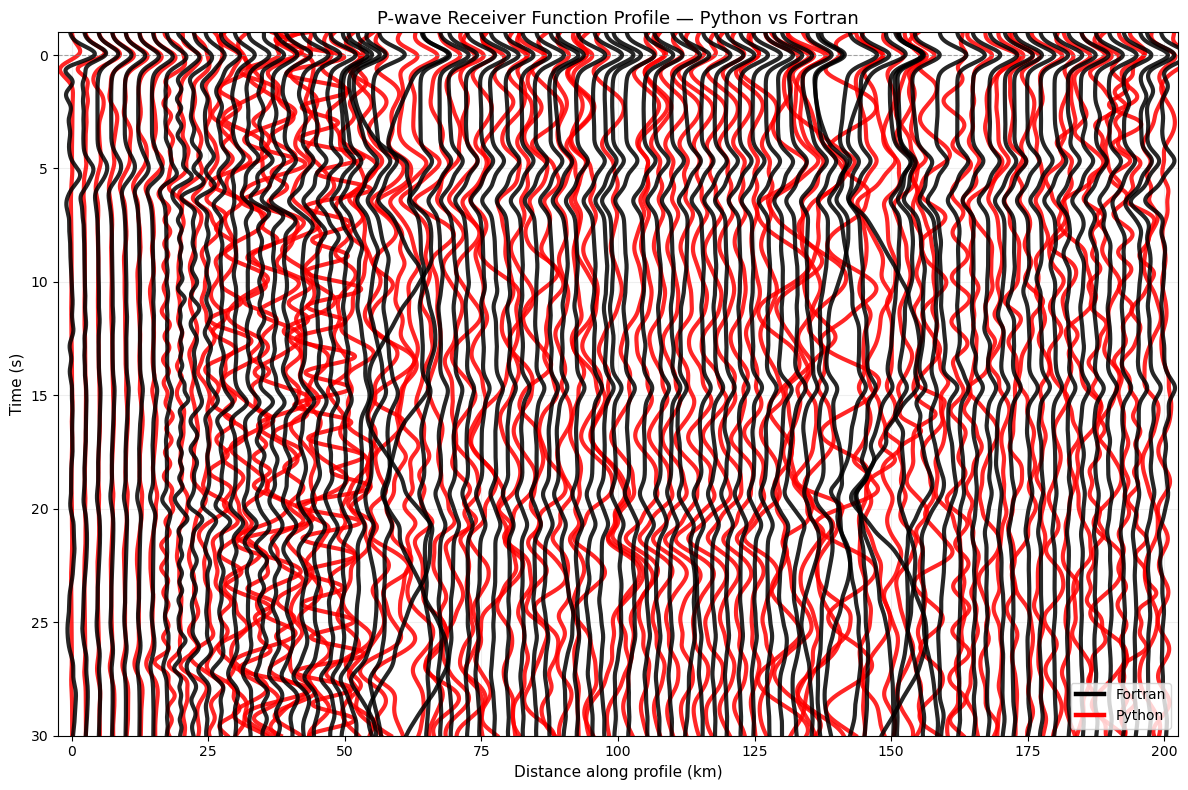

Saved rf_profile_comparison.png

RF trace-by-trace CC (post-P): mean=0.2249, min=-0.6593, max=0.7659


In [7]:
# --- Receiver Function profile comparison ---

from rf import compute_prf
import importlib
import plots.rf as _plots_rf
importlib.reload(_plots_rf)
from plots.rf import sac_power_wiggle, rf_power_law, rf_amp_percentile

# RF parameters
RF_TSHIFT = 10.0    # seconds before direct P
RF_TMIN = -1.0      # display window start (s)
RF_TMAX = 30.0      # display window end (s)
RF_F0 = 2.0         # Gaussian width factor
RF_WLEVEL = 1e-6    # water level (tuned for synthetic data; see 0_rf_compute_test.ipynb)
RF_METHOD = "water"
RF_DECIMATE = max(1, nrcv // 80)
RF_POWER = 1.0     # >1 emphasizes strong phases; 1 = linear; <1 boosts weak
RF_AMP_PERCENTILE = 90.0  # normalize by this percentile of |powered| amp (post-P/S)

print("Computing P-wave receiver functions...")
print(f"  tshift={RF_TSHIFT} s, f0={RF_F0}, wlevel={RF_WLEVEL}, method={RF_METHOD}")

rf_py, t_rf, rms_py = compute_prf(
    result.ux, result.uz, config.dt,
    tshift=RF_TSHIFT, f0=RF_F0, method=RF_METHOD, wlevel=RF_WLEVEL,
)
rf_fort, _, rms_fort = compute_prf(
    f_seisx, f_seisz, config.dt,
    tshift=RF_TSHIFT, f0=RF_F0, method=RF_METHOD, wlevel=RF_WLEVEL,
)

print(f"  RF shape: {rf_py.shape}, t_rf range: [{t_rf[0]:.1f}, {t_rf[-1]:.1f}] s")
print(f"  Python  mean RMS: {rms_py.mean():.4f}")
print(f"  Fortran mean RMS: {rms_fort.mean():.4f}")

# --- RF section plot: distance vs time (time downward) ---

rx_km = ex.rx / 1000.0
plot_idx = np.arange(0, nrcv, RF_DECIMATE)

# Display mask (includes pre-P from -1 s)
t_mask = (t_rf >= RF_TMIN) & (t_rf <= RF_TMAX)
t_plot = t_rf[t_mask]

# Post-arrival mask for shared amplitude scaling
post_p_mask = (t_rf > 0) & (t_rf <= RF_TMAX)

# Bin size = mean receiver spacing along the plotted profile
if len(plot_idx) > 1:
    bin_size_km = float(np.mean(np.diff(rx_km[plot_idx])))
else:
    bin_size_km = 1.0

# One scale for all traces: max |RF| after P maps to full bin width
# Power transform first, then shared normalization to bin width
rf_py_pow = rf_power_law(rf_py, RF_POWER)
rf_fort_pow = rf_power_law(rf_fort, RF_POWER)

amp_ref = rf_amp_percentile(
    rf_py_pow, rf_fort_pow,
    mask=post_p_mask,
    percentile=RF_AMP_PERCENTILE,
)
print(
    f"  bin_size={bin_size_km:.3f} km, "
    f"post-power p{RF_AMP_PERCENTILE:.0f} amp_ref={amp_ref:.4e}, power={RF_POWER}"
)

RF_LW = 3.0

fig, ax = plt.subplots(figsize=(12, 8))

for idx in plot_idx:
    x0 = rx_km[idx]
    tr_fort = sac_power_wiggle(
        rf_fort[idx, t_mask], amp_ref, bin_size_km, power=RF_POWER
    )
    tr_py = sac_power_wiggle(
        rf_py[idx, t_mask], amp_ref, bin_size_km, power=RF_POWER
    )

    ax.plot(x0 + tr_fort, t_plot, color="k", lw=RF_LW, alpha=0.85,zorder=3)
    ax.plot(x0 + tr_py, t_plot, color="r", lw=RF_LW, alpha=0.85,zorder=2)

ax.plot([], [], "k-", lw=RF_LW + 0.2, label="Fortran")
ax.plot([], [], "r-", lw=RF_LW + 0.2, label="Python")
ax.legend(loc="lower right", fontsize=10)

ax.set_xlabel("Distance along profile (km)", fontsize=11)
ax.set_ylabel("Time (s)", fontsize=11)
ax.set_title("P-wave Receiver Function Profile — Python vs Fortran", fontsize=13)
ax.set_ylim(RF_TMAX, RF_TMIN)
ax.set_xlim(rx_km[plot_idx[0]] - bin_size_km, rx_km[plot_idx[-1]] + bin_size_km)
ax.axhline(0.0, color="0.5", ls="--", lw=0.8, alpha=0.7)
ax.grid(alpha=0.2)

plt.tight_layout()
out_rf_png = BENCH_DIR / "output" / "benchmark" / "rf_profile_comparison.png"
plt.savefig(out_rf_png, dpi=150)
plt.show()
print(f"Saved {out_rf_png.name}")

# Per-trace RF correlation (post-P window)
rf_cc = np.array([
    np.corrcoef(rf_py[i, post_p_mask], rf_fort[i, post_p_mask])[0, 1]
    for i in range(nrcv)
])
print(f"\nRF trace-by-trace CC (post-P): mean={np.nanmean(rf_cc):.4f}, "
      f"min={np.nanmin(rf_cc):.4f}, max={np.nanmax(rf_cc):.4f}")


## Wavefield snapshot comparison

Compare 2-D displacement snapshots (`ux`, `uz`) between Fortran FDFK2D and the
Python hybrid solver at selected time steps.

The plot below is organized as a compact snapshot matrix: columns are time steps,
and rows are Fortran, Python, and Python − Fortran. A robust symmetric color
scale is shared by the Fortran/Python rows (one colorbar), while all difference
panels share a single global symmetric scale and one unified colorbar per
component figure so small residuals remain visible and directly comparable.

**Prerequisites**

- Fortran snapshots: `benchmark/<case>/snapshots/{it:05d}{ux,uz}.su`, produced when
  FDFK2D runs with `outsnap=.true.` in `input/FD_model.dat` (see
  `input/FD_model.with_snapshots.dat`, `nstep=100`).
- Python snapshots: computed below with `snapshot_interval=nstep` (disables the
  Numba fast path and is much slower). Results are cached under
  `output/python/snapshots/` for reuse.

If Fortran snapshots are missing, only the Python wavefield is shown and a note
is printed with regeneration instructions.

In [8]:
# --- Snapshot helpers ---

import glob
import re

from fk.io_fortran import read_fd_model, read_traces

fd_snap = read_fd_model(input_dir / "FD_model.with_snapshots.dat")
SNAP_INTERVAL = fd_snap.nstep
print(f"Snapshot interval: every {SNAP_INTERVAL} steps ({SNAP_INTERVAL * config.dt:.2f} s)")

snap_dir_fortran = BENCH_DIR / "snapshots"
snap_dir_python = BENCH_DIR / "output" / "python" / "snapshots"

extent_km = [fd.x0 / 1000, fd.xn / 1000, fd.zn / 1000, fd.z0 / 1000]


def discover_snapshots(snap_dir: Path, comp: str) -> list[tuple[int, Path]]:
    """Return sorted (timestep, path) pairs for Fortran-style snapshot files."""
    pattern = str(snap_dir / f"*{comp}.su")
    regex = re.compile(r"(\d{5})" + re.escape(comp) + r"\.su$")
    results = []
    for f in glob.glob(pattern):
        m = regex.search(f)
        if m:
            results.append((int(m.group(1)), Path(f)))
    results.sort(key=lambda x: x[0])
    return results


def load_fortran_snapshot(path: Path) -> np.ndarray:
    """Load one Fortran snapshot SU file -> array (nz, nx)."""
    data, _ = read_traces(path)  # (nx, nz)
    return data.T


def snapshot_field_metrics(ref: np.ndarray, test: np.ndarray) -> dict:
    """CC, NRMSE, and least-squares scale (test scaled to ref)."""
    ref64 = ref.astype(np.float64)
    test64 = test.astype(np.float64)
    denom = float(np.dot(test64.ravel(), test64.ravel()))
    scale = float(np.dot(ref64.ravel(), test64.ravel()) / denom) if denom > 1e-30 else 1.0
    test_s = scale * test64
    ref_dm = ref64 - ref64.mean()
    test_dm = test_s - test_s.mean()
    denom_cc = np.linalg.norm(ref_dm) * np.linalg.norm(test_dm)
    cc = float(np.dot(ref_dm.ravel(), test_dm.ravel()) / denom_cc) if denom_cc > 1e-30 else 0.0
    rms_ref = np.sqrt(np.mean(ref64 ** 2))
    nrmse = float(np.sqrt(np.mean((ref64 - test_s) ** 2)) / rms_ref) if rms_ref > 1e-30 else float("nan")
    return {"cc": cc, "nrmse": nrmse, "scale": scale}


def save_python_snapshots(result, snap_dir: Path, interval: int) -> None:
    """Cache Python snapshots using the Fortran filename convention."""
    snap_dir.mkdir(parents=True, exist_ok=True)
    for i, (ux_snap, uz_snap) in enumerate(zip(result.snapshots_ux, result.snapshots_uz)):
        it = i * interval
        write_su(snap_dir / f"{it:05d}ux.su", ux_snap.T.astype(np.float32), config.dt)
        write_su(snap_dir / f"{it:05d}uz.su", uz_snap.T.astype(np.float32), config.dt)
    print(f"Cached {len(result.snapshots_uz)} Python snapshot pairs to {snap_dir}")

Snapshot interval: every 100 steps (1.00 s)


In [9]:
# --- Run or load Python snapshots ---

FORCE_SNAPSHOT_REGEN = True  # regen cached snapshots
RUN_SNAPSHOT_SIM = FORCE_SNAPSHOT_REGEN or not any(snap_dir_python.glob("*uz.su"))

if RUN_SNAPSHOT_SIM:
    print("Running Python hybrid with snapshots (slow path; expect several minutes)...")
    t0 = time.perf_counter()
    snap_result = compute_hybrid_seismograms(
        config,
        model_left,
        model_right,
        ex.source,
        p_si,
        receivers_x=ex.rx,
        receivers_z=ex.rz,
        vp_2d=vp_2d,
        vs_2d=vs_2d,
        rho_2d=rho_2d,
        phi=ex.phi,
        z_init=z_init,
        bwf_pad_factor=BWF_PAD_FACTOR,  # anti-wraparound: synthesise on ~2x time axis
        verbose=True,
        snapshot_interval=SNAP_INTERVAL,
    )
    print(f"Snapshot simulation wall time: {time.perf_counter() - t0:.1f} s")
    save_python_snapshots(snap_result, snap_dir_python, SNAP_INTERVAL)
else:
    print(f"Using cached Python snapshots in {snap_dir_python}")

fort_uz_snaps = discover_snapshots(snap_dir_fortran, "uz")
py_uz_snaps = discover_snapshots(snap_dir_python, "uz")
print(f"Fortran uz snapshots: {len(fort_uz_snaps)} in {snap_dir_fortran}")
print(f"Python  uz snapshots: {len(py_uz_snaps)} in {snap_dir_python}")

if not fort_uz_snaps:
    print("\nNOTE: No Fortran snapshots found.")
    print("  Re-run FDFK2D with snapshots enabled, e.g.:")
    print(f"    cd {BENCH_DIR.relative_to(PROJECT_ROOT)}")
    print("    cp input/FD_model.with_snapshots.dat input/FD_model.dat")
    print("    sbatch submit.sbatch   # or run FDFK2D locally")

common_its = sorted({it for it, _ in fort_uz_snaps} & {it for it, _ in py_uz_snaps})
candidate_its = [100, 500, 1000, 1500, 2000, 2500, 3000]
SELECTED_ITS = [it for it in candidate_its if it in common_its]
if not SELECTED_ITS and common_its:
    SELECTED_ITS = common_its[::max(1, len(common_its) // 4)][:4]
elif not SELECTED_ITS and py_uz_snaps:
    SELECTED_ITS = [it for it in candidate_its if it in {t for t, _ in py_uz_snaps}]
    if not SELECTED_ITS:
        SELECTED_ITS = [py_uz_snaps[len(py_uz_snaps) // 3][0],
                      py_uz_snaps[len(py_uz_snaps) // 2][0],
                      py_uz_snaps[2 * len(py_uz_snaps) // 3][0]]
print(f"Selected time steps for comparison: {SELECTED_ITS}")

Running Python hybrid with snapshots (slow path; expect several minutes)...
[Hybrid] Computing FK background wavefield (nz=251, nx=1001, nt=4001)...
[Hybrid] Background wavefield memory: 1472.0 MB
[Hybrid] Initializing FD solver...
[Hybrid] Time-stepping: 4001 steps, dt=0.01000s...
[Hybrid] Simulation complete.
Snapshot simulation wall time: 98.5 s
Cached 41 Python snapshot pairs to /Users/jygong/Stanford/Courses/GP245 Computational Earthsystem Analysis/Final Project/FDFK_Python/benchmark/test1_P_out/output/python/snapshots
Fortran uz snapshots: 40 in /Users/jygong/Stanford/Courses/GP245 Computational Earthsystem Analysis/Final Project/FDFK_Python/benchmark/test1_P_out/snapshots
Python  uz snapshots: 41 in /Users/jygong/Stanford/Courses/GP245 Computational Earthsystem Analysis/Final Project/FDFK_Python/benchmark/test1_P_out/output/python/snapshots
Selected time steps for comparison: [100, 500, 1000, 1500, 2000, 2500, 3000]


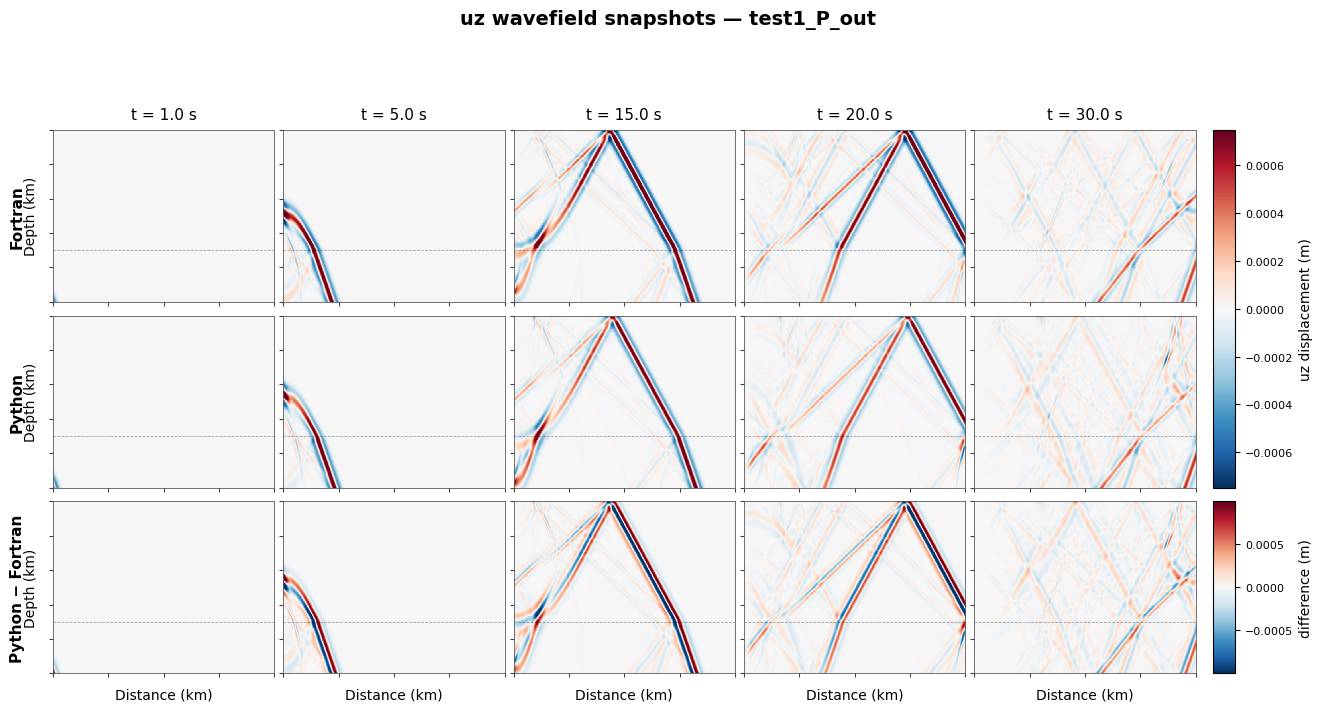

Saved snapshot_matrix_uz.png


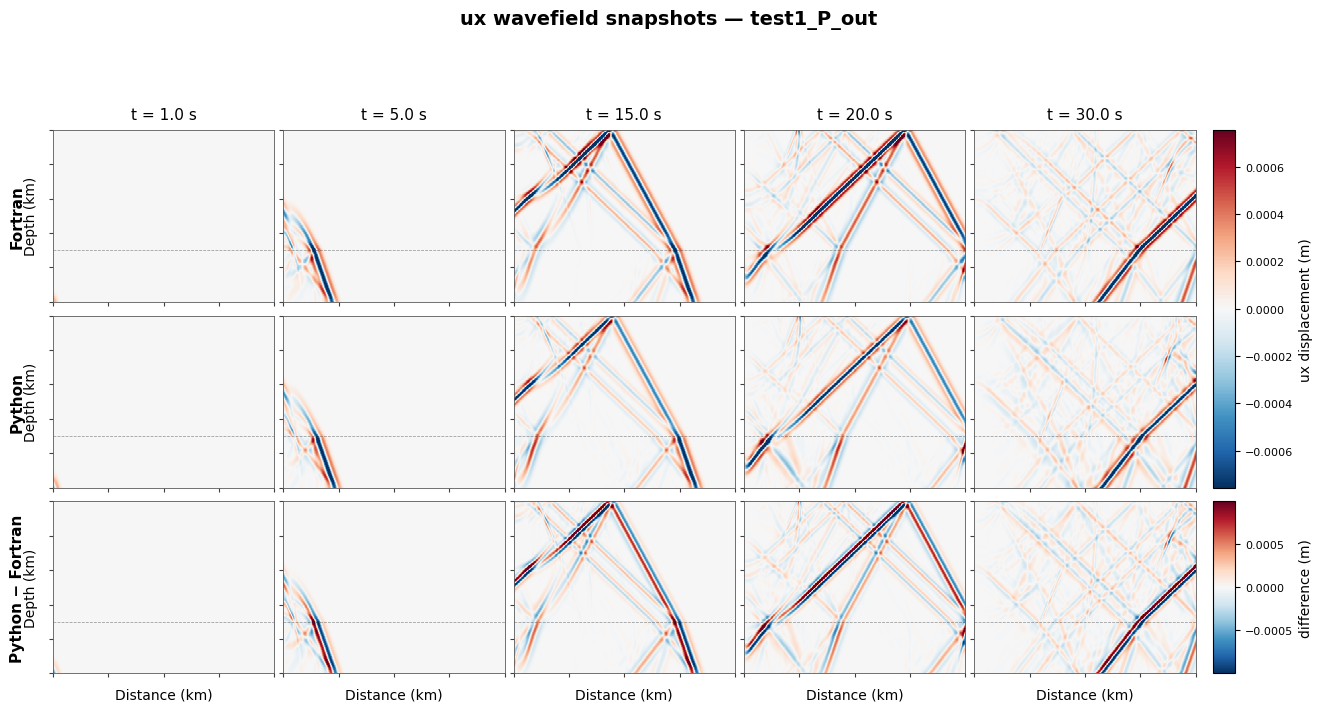

Saved snapshot_matrix_ux.png

Snapshot field metrics (Python scaled to Fortran):
comp     t(s)       CC      NRMSE      scale
  uz     1.00   0.3236     0.9459     0.1998
  uz     5.00   0.2058     0.9786     0.2299
  uz    15.00   0.1807     0.9835     0.2323
  uz    20.00   0.1582     0.9874     0.2203
  uz    30.00   0.0698     0.9976     0.0723
  ux     1.00   0.3220     0.9465     0.1977
  ux     5.00   0.1798     0.9837     0.1869
  ux    15.00   0.1720     0.9851     0.2198
  ux    20.00   0.1774     0.9841     0.2379
  ux    30.00   0.1452     0.9894     0.1780


In [10]:
# --- Publication-style snapshot matrix ---

SNAPSHOT_MAX_COLUMNS = 5
SNAPSHOT_PERCENTILE = 99.5
SNAPSHOT_COMPONENTS = ("uz", "ux")

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from plots.wavefield_snapshots import annotate_interfaces, model_interface_profiles


def choose_snapshot_steps(steps: list[int], max_columns: int = SNAPSHOT_MAX_COLUMNS) -> list[int]:
    """Select evenly spaced time steps for a readable panel figure."""
    if len(steps) <= max_columns:
        return steps
    idx = np.linspace(0, len(steps) - 1, max_columns, dtype=int)
    return [steps[i] for i in idx]


def symmetric_limit(arrays: list[np.ndarray], percentile: float = SNAPSHOT_PERCENTILE) -> float:
    """Robust symmetric color limit across a list of wavefield arrays."""
    values = np.concatenate([np.ravel(np.abs(a[np.isfinite(a)])) for a in arrays])
    if values.size == 0:
        return 1.0
    limit = float(np.percentile(values, percentile))
    return limit if limit > 1e-30 else 1.0


def style_snapshot_axis(ax, *, show_xlabel: bool, show_ylabel: bool) -> None:
    ax.set_xlim(fd.x0 / 1000, fd.xn / 1000)
    ax.set_ylim(fd.zn / 1000, fd.z0 / 1000)
    ax.tick_params(labelsize=9, length=3, color="0.25")
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color("0.35")
    if show_xlabel:
        ax.set_xlabel("Distance (km)", fontsize=10)
    else:
        ax.set_xlabel("")
        ax.set_xticklabels([])
    if show_ylabel:
        ax.set_ylabel("Depth (km)", fontsize=10)
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])


def plot_snapshot_matrix(comp: str, selected_steps: list[int]) -> list[dict]:
    """Plot Fortran/Python/difference snapshots for one component."""
    fort_lookup = dict(discover_snapshots(snap_dir_fortran, comp))
    py_lookup = dict(discover_snapshots(snap_dir_python, comp))
    available_steps = [it for it in selected_steps if it in py_lookup]
    if not available_steps:
        print(f"Skipping {comp}: no Python snapshots at selected time steps.")
        return []

    plot_steps = choose_snapshot_steps(available_steps)
    has_fortran = all(it in fort_lookup for it in plot_steps)
    row_labels = ["Fortran", "Python", "Python − Fortran"] if has_fortran else ["Python"]
    nrows = len(row_labels)
    ncols = len(plot_steps)

    py_fields = {it: load_fortran_snapshot(py_lookup[it]) for it in plot_steps}
    fort_fields = {it: load_fortran_snapshot(fort_lookup[it]) for it in plot_steps} if has_fortran else {}
    diff_fields = {it: py_fields[it] - fort_fields[it] for it in plot_steps} if has_fortran else {}

    wave_limit = symmetric_limit(
        list(py_fields.values()) + list(fort_fields.values()), SNAPSHOT_PERCENTILE
    )
    diff_limit = symmetric_limit(list(diff_fields.values()), SNAPSHOT_PERCENTILE) if has_fortran else None
    interface_profiles = model_interface_profiles(vs_2d, config.x0, config.dx, fd.z0, fd.dz)

    fig_width = max(11.0, 2.65 * ncols + 1.4)
    fig_height = 2.15 * nrows + 1.1
    with plt.rc_context({
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    }):
        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(fig_width, fig_height),
            sharex=True,
            sharey=True,
            squeeze=False,
            constrained_layout=False,
        )
        fig.subplots_adjust(left=0.08, right=0.86, top=0.84, bottom=0.12,
                            wspace=0.04, hspace=0.08)

        wave_norm = Normalize(vmin=-wave_limit, vmax=wave_limit)
        diff_norm = (
            Normalize(vmin=-diff_limit, vmax=diff_limit) if has_fortran else None
        )
        wave_im = None
        for col, it in enumerate(plot_steps):
            t_sec = it * config.dt
            axes[0, col].set_title(f"t = {t_sec:.1f} s", pad=8)

            if has_fortran:
                panel_data = [fort_fields[it], py_fields[it], diff_fields[it]]
            else:
                panel_data = [py_fields[it]]

            for row, data in enumerate(panel_data):
                is_diff = has_fortran and row == 2
                im = axes[row, col].imshow(
                    data,
                    aspect="auto",
                    cmap="RdBu_r",
                    norm=diff_norm if is_diff else wave_norm,
                    extent=extent_km,
                    interpolation="nearest",
                    rasterized=True,
                )
                if not is_diff and wave_im is None:
                    wave_im = im
                annotate_interfaces(axes[row, col], interface_profiles)
                style_snapshot_axis(
                    axes[row, col],
                    show_xlabel=(row == nrows - 1),
                    show_ylabel=(col == 0),
                )
                if col == 0:
                    axes[row, col].text(
                        -0.16, 0.5, row_labels[row], transform=axes[row, col].transAxes,
                        rotation=90, va="center", ha="center", fontsize=11,
                        fontweight="semibold",
                    )

        title = f"{comp} wavefield snapshots — {BENCH_DIR.name}"
        fig.suptitle(title, fontsize=14, fontweight="semibold", y=1.0)
        # fig.text(0.08, 0.895,
        #          f"Shared wavefield scale: ±{wave_limit:.2e} m"
        #          + (f"   |   Difference scale: ±{diff_limit:.2e} m" if has_fortran else ""),
        #          fontsize=9, color="0.30")

        if wave_im is not None:
            top_pos = axes[0, -1].get_position()
            wave_bot_row = 1 if has_fortran else 0
            bot_pos = axes[wave_bot_row, -1].get_position()
            cax_wave = fig.add_axes([
                top_pos.x1 + 0.012, bot_pos.y0, 0.015, top_pos.y1 - bot_pos.y0,
            ])
            cb = fig.colorbar(wave_im, cax=cax_wave)
            cb.set_label(f"{comp} displacement (m)", fontsize=10)
            cb.ax.tick_params(labelsize=8)

        if has_fortran and diff_norm is not None:
            diff_pos = axes[2, -1].get_position()
            diff_sm = ScalarMappable(norm=diff_norm, cmap="RdBu_r")
            diff_sm.set_array([])
            cax_diff = fig.add_axes([
                diff_pos.x1 + 0.012, diff_pos.y0, 0.015, diff_pos.height,
            ])
            cb_diff = fig.colorbar(diff_sm, cax=cax_diff)
            cb_diff.set_label("difference (m)", fontsize=10)
            cb_diff.ax.tick_params(labelsize=8)

        out_png = BENCH_DIR / "output" / "benchmark" / f"snapshot_matrix_{comp}.png"
        out_png.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(out_png, dpi=220, bbox_inches="tight")
        plt.show()
        print(f"Saved {out_png.name}")

    rows = []
    if has_fortran:
        for it in plot_steps:
            rows.append({
                "comp": comp,
                "it": it,
                "t_s": it * config.dt,
                **snapshot_field_metrics(fort_fields[it], py_fields[it]),
            })
    return rows


if not SELECTED_ITS:
    print("No snapshot time steps available for comparison.")
else:
    metrics_rows = []
    for comp in SNAPSHOT_COMPONENTS:
        metrics_rows.extend(plot_snapshot_matrix(comp, SELECTED_ITS))

    if metrics_rows:
        print("\nSnapshot field metrics (Python scaled to Fortran):")
        print(f"{'comp':>4} {'t(s)':>8} {'CC':>8} {'NRMSE':>10} {'scale':>10}")
        for row in metrics_rows:
            print(f"{row['comp']:>4} {row['t_s']:8.2f} {row['cc']:8.4f} {row['nrmse']:10.4f} {row['scale']:10.4f}")


## Interpretation

**If `uz` passes but `ux` looks wrong:**
- By default, `compute_hybrid_seismograms` applies the Fortran-compatible `cos(phi)`
  post-rotation (`fortran_seisx_convention=True`), so `result.ux` should match Fortran
  `seisx.su` directly. If you disabled this flag, the single-cos ux will differ in
  polarity when `cos(phi) < 0`.

**If `uz` fails:**
- Check FD coefficients: run `pytest tests/test_fd_fortran_coefficients.py`
- Check injection logic: run `pytest tests/test_hybrid_injection.py`
- Compare grid dimensions, `norder`, and `npml` with Fortran input deck
- Verify `z_init` computation matches Fortran

**To re-run the full benchmark pipeline:**
```bash
cd benchmark/test1_P_out
python run_python_benchmark.py
python summarize_benchmark.py
```

**To regenerate Fortran snapshots:**
```bash
cp input/FD_model.with_snapshots.dat input/FD_model.dat
sbatch submit.sbatch
```
